In [1]:
import rasterio
import pandas as pd
import numpy as np
import glob
import os
import gc
from pathlib import Path

In [9]:
import rasterio
import pandas as pd
import numpy as np
from pathlib import Path
import gc
import time

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project\\tiff_files")
PARTIAL_DIR = LOCAL_DIR / 'partial'
PARTIAL_DIR.mkdir(exist_ok=True)
REGION = 'R2'

tile_paths = sorted(LOCAL_DIR.glob(f'all_pixels_{REGION}_v2-*.tif'))
print(f'Found {len(tile_paths)} tiles')

t_start = time.time()
for i, path in enumerate(tile_paths):
    out_path = PARTIAL_DIR / f'tile_{i:04d}.parquet'
    if out_path.exists():
        print(f'  [{i+1}/{len(tile_paths)}] {path.name}: skipped (already done)')
        continue
    
    t0 = time.time()
    try:
        with rasterio.open(path) as src:
            band_names = list(src.descriptions)
            transform = src.transform
            
            # Read all 70 bands at once - much faster than 70 separate reads
            all_bands = src.read()  # shape: (n_bands, height, width)
            
            melt_band = all_bands[0]
            ice_mask = ~np.isnan(melt_band) & np.isin(melt_band, [0.0, 1.0])
            n_ice = ice_mask.sum()
            
            if n_ice == 0:
                pd.DataFrame().to_parquet(out_path)
                del all_bands
                gc.collect()
                continue
            
            rows_idx, cols_idx = np.where(ice_mask)
            
            # Index all bands at once at the ice locations
            data = all_bands[:, rows_idx, cols_idx]  # shape: (n_bands, n_ice)
            
            lons, lats = rasterio.transform.xy(transform, rows_idx, cols_idx)
            df_tile = pd.DataFrame(data.T, columns=band_names)
            df_tile['lon'] = lons
            df_tile['lat'] = lats
            df_tile.to_parquet(out_path)
            
            del all_bands, data, df_tile
            gc.collect()
        
        tile_time = time.time() - t0
        elapsed = time.time() - t_start
        # Estimate remaining time
        avg_per_tile = elapsed / (i + 1)
        remaining = avg_per_tile * (len(tile_paths) - i - 1)
        print(f'  [{i+1}/{len(tile_paths)}] {path.name}: '
              f'{n_ice:,} pixels ({tile_time:.1f}s, '
              f'total {elapsed/60:.1f}min, ETA {remaining/60:.1f}min)')
    
    except Exception as e:
        print(f'  FAILED: {path.name}: {e}')
        continue

# Concat once all tiles processed
print('\nConcatenating partial files...')
parquet_files = sorted(PARTIAL_DIR.glob('*.parquet'))
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)
    if len(df) > 0:
        dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df['melt_label'] = df['melt_label'].astype(int)
df.to_csv(LOCAL_DIR / f'{REGION.lower()}_combined.csv', index=False)

print(f'\n=== {REGION} LOADED ===')
print(f'Shape: {df.shape}')
print(f'Melt rate: {df["melt_label"].mean()*100:.2f}%')

Found 84 tiles
  [1/84] all_pixels_R2_v2-0000000000-0000000000.tif: 182,088 pixels (50.5s, total 0.8min, ETA 69.8min)
  [2/84] all_pixels_R2_v2-0000000000-0000004096.tif: 545,700 pixels (36.9s, total 1.5min, ETA 59.7min)
  [3/84] all_pixels_R2_v2-0000000000-0000008192.tif: 192,293 pixels (31.8s, total 2.0min, ETA 53.6min)
  [4/84] all_pixels_R2_v2-0000000000-0000012288.tif: 96,391 pixels (29.4s, total 2.5min, ETA 49.5min)
  [13/84] all_pixels_R2_v2-0000004096-0000000000.tif: 29,775 pixels (24.5s, total 6.0min, ETA 32.9min)
  [14/84] all_pixels_R2_v2-0000004096-0000004096.tif: 407,777 pixels (26.1s, total 6.5min, ETA 32.3min)
  [15/84] all_pixels_R2_v2-0000004096-0000008192.tif: 12,651 pixels (25.5s, total 6.9min, ETA 31.7min)
  [18/84] all_pixels_R2_v2-0000004096-0000020480.tif: 263,761 pixels (25.1s, total 8.1min, ETA 29.8min)
  [19/84] all_pixels_R2_v2-0000004096-0000024576.tif: 59,902 pixels (25.0s, total 8.6min, ETA 29.3min)
  [30/84] all_pixels_R2_v2-0000008192-0000020480.tif: 1,2

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project\\Merged")
df = pd.read_csv(LOCAL_DIR / 'r2_combined.csv')

# ============================================================
# 1. STRUCTURE CHECK
# ============================================================
print('=== STRUCTURE ===')
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):')
print(f'  First 8: {df.columns.tolist()[:8]}')
print(f'  Last 5:  {df.columns.tolist()[-5:]}')

# Identify which columns are AlphaEarth bands
ae_cols = [c for c in df.columns if c.startswith('A') and len(c) == 3 and c[1:].isdigit()]
non_ae_cols = [c for c in df.columns if c not in ae_cols]
print(f'\nAlphaEarth bands found: {len(ae_cols)}')
print(f'  Range: {ae_cols[0]} to {ae_cols[-1]}')
print(f'Non-AE columns: {non_ae_cols}')

# ============================================================
# 2. NULL CHECKS
# ============================================================
print('\n=== NULLS ===')
nulls = df.isna().sum()
nulls_with_data = nulls[nulls > 0]
if len(nulls_with_data) == 0:
    print('No nulls anywhere ✓')
else:
    print(f'Columns with nulls:\n{nulls_with_data}')

# ============================================================
# 3. ALPHAEARTH STATISTICS
# ============================================================
print('\n=== ALPHAEARTH SUMMARY ===')
ae_data = df[ae_cols].values
print(f'Overall min: {ae_data.min():.4f}')
print(f'Overall max: {ae_data.max():.4f}')
print(f'Overall mean: {ae_data.mean():.4f}')
print(f'Overall std: {ae_data.std():.4f}')

# Per-band statistics for first/middle/last few bands
print('\nPer-band stats (first 5, middle 5, last 5 bands):')
sample_bands = ae_cols[:5] + ae_cols[30:35] + ae_cols[-5:]
print(df[sample_bands].describe().T[['mean', 'std', 'min', 'max']].round(4))

# ============================================================
# 4. SPOT CHECK A FEW PIXELS
# ============================================================
print('\n=== SPOT CHECK: 3 random ice pixels ===')
sample_rows = df.sample(n=3, random_state=42)
for idx, row in sample_rows.iterrows():
    print(f'\nPixel at ({row["lon"]:.4f}, {row["lat"]:.4f}):')
    print(f'  melt_label: {row["melt_label"]}')
    print(f'  elevation: {row["elevation"]:.1f}, slope: {row["slope"]:.1f}, '
          f'aspect: {row["aspect"]:.1f}, edge_dist: {row["edge_distance"]:.1f}')
    ae_values = row[ae_cols].values.astype(float)
    print(f'  AE bands: min={ae_values.min():.3f}, max={ae_values.max():.3f}, '
          f'mean={ae_values.mean():.3f}, std={ae_values.std():.3f}')
    print(f'  First 5 AE values: {ae_values[:5].round(3)}')

# ============================================================
# 5. CONSTANT BANDS CHECK
# ============================================================
print('\n=== CONSTANT BANDS CHECK ===')
band_stds = df[ae_cols].std()
near_zero_std = band_stds[band_stds < 1e-6]
if len(near_zero_std) > 0:
    print(f'WARNING: {len(near_zero_std)} bands have near-zero std (likely broken):')
    print(near_zero_std)
else:
    print(f'All {len(ae_cols)} AE bands have meaningful variance ✓')
    print(f'Std range across bands: {band_stds.min():.4f} to {band_stds.max():.4f}')

# ============================================================
# 6. CORRELATION SANITY CHECK
# ============================================================
print('\n=== ICE/MELT SEPARATION ===')
melt_means = df[df['melt_label'] == 1][ae_cols].mean()
nonmelt_means = df[df['melt_label'] == 0][ae_cols].mean()
mean_diff = (melt_means - nonmelt_means).abs()
print(f'Bands with biggest mean difference (melt vs non-melt):')
print(mean_diff.nlargest(5).round(4))
print(f'\nThis is just a sanity check — non-zero diffs mean AE distinguishes melt from non-melt at all.')

=== STRUCTURE ===
Shape: (6217318, 71)
Columns (71):
  First 8: ['melt_label', 'elevation', 'aspect', 'slope', 'edge_distance', 'A00', 'A01', 'A02']
  Last 5:  ['A61', 'A62', 'A63', 'lon', 'lat']

AlphaEarth bands found: 64
  Range: A00 to A63
Non-AE columns: ['melt_label', 'elevation', 'aspect', 'slope', 'edge_distance', 'lon', 'lat']

=== NULLS ===
No nulls anywhere ✓

=== ALPHAEARTH SUMMARY ===
Overall min: -0.4764
Overall max: 0.4340
Overall mean: -0.0181
Overall std: 0.1237

Per-band stats (first 5, middle 5, last 5 bands):
       mean     std     min     max
A00 -0.0395  0.0320 -0.2069  0.0842
A01 -0.0904  0.0389 -0.3553  0.1085
A02 -0.2000  0.0357 -0.3647  0.0022
A03  0.0489  0.0500 -0.1600  0.2141
A04 -0.1195  0.0488 -0.3278  0.0554
A30 -0.0290  0.0513 -0.2520  0.2442
A31  0.0664  0.0509 -0.1246  0.2680
A32 -0.0904  0.0460 -0.3101  0.0984
A33  0.0005  0.0624 -0.2141  0.1929
A34 -0.0860  0.0505 -0.3369  0.1137
A59 -0.1151  0.0453 -0.3189  0.0888
A60 -0.0847  0.0391 -0.2141  0.14

In [13]:
import pandas as pd
from pathlib import Path
import time

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project\\Merged")  # adjust
REGIONS = ['R1a', 'R1b', 'R2', 'R3']

for region in REGIONS:
    csv_path = LOCAL_DIR / f'{region.lower()}_combined.csv'
    parquet_path = LOCAL_DIR / f'{region.lower()}_combined.parquet'
    
    if parquet_path.exists():
        print(f'{region}: parquet already exists, skipping')
        continue
    
    t0 = time.time()
    print(f'{region}: loading CSV...')
    df = pd.read_csv(csv_path)
    
    print(f'  Loaded {len(df):,} rows in {time.time()-t0:.1f}s')
    print(f'  Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
    
    # Cast numeric columns to float32 to save memory
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
    
    print(f'  Memory after float32: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
    
    df.to_parquet(parquet_path, compression='snappy', index=False)
    print(f'  Saved parquet: {parquet_path.stat().st_size / 1e9:.2f} GB')
    print(f'  Total time: {time.time()-t0:.1f}s\n')

print('Done.')

R1a: loading CSV...
  Loaded 6,222,913 rows in 103.6s
  Memory: 3.53 GB
  Memory after float32: 1.79 GB
  Saved parquet: 0.38 GB
  Total time: 123.8s

R1b: loading CSV...
  Loaded 1,028,089 rows in 14.1s
  Memory: 0.58 GB
  Memory after float32: 0.30 GB
  Saved parquet: 0.06 GB
  Total time: 18.1s

R2: loading CSV...
  Loaded 6,217,318 rows in 443.0s
  Memory: 3.53 GB
  Memory after float32: 1.79 GB
  Saved parquet: 0.38 GB
  Total time: 546.5s

R3: loading CSV...
  Loaded 1,774,319 rows in 115.9s
  Memory: 1.01 GB
  Memory after float32: 0.51 GB
  Saved parquet: 0.11 GB
  Total time: 140.2s

Done.


In [14]:
import pandas as pd
from pathlib import Path

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project\\Merged")
REGIONS = ['R1a', 'R1b', 'R2', 'R3']

dfs = []
for region in REGIONS:
    df = pd.read_parquet(LOCAL_DIR / f'{region.lower()}_combined.parquet')
    df['region'] = region
    dfs.append(df)
    print(f'{region}: {len(df):,} pixels, '
          f'{df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nCombined Peru-wide: {len(df_all):,} pixels')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print(f'Melt rate: {df_all["melt_label"].mean()*100:.2f}%')
print(f'Per region:\n{df_all.groupby("region")["melt_label"].agg(["count", "mean"])}')

R1a: 6,222,913 pixels, 2.17 GB
R1b: 1,028,089 pixels, 0.36 GB
R2: 6,217,318 pixels, 2.16 GB
R3: 1,774,319 pixels, 0.62 GB

Combined Peru-wide: 15,242,639 pixels
Memory: 5.30 GB
Melt rate: 19.50%
Per region:
          count      mean
region                   
R1a     6222913  0.138783
R1b     1028089  0.263844
R2      6217318  0.226895
R3      1774319  0.240157


In [15]:
# ============================================================
# CELL 1: LOAD COMBINED DATASET
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path
import time

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project\\Merged")
REGIONS = ['R1a', 'R1b', 'R2', 'R3']

t0 = time.time()
dfs = []
for region in REGIONS:
    df = pd.read_parquet(LOCAL_DIR / f'{region.lower()}_combined.parquet')
    df['region'] = region
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(df_all):,} pixels in {time.time()-t0:.1f}s')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# Identify AE columns
ae_cols = [c for c in df_all.columns 
           if c.startswith('A') and len(c) == 3 and c[1:].isdigit()]
print(f'AlphaEarth bands: {len(ae_cols)} (expected 64)')
assert len(ae_cols) == 64, 'Wrong number of AE bands'

Loaded 15,242,639 pixels in 19.4s
Memory: 5.30 GB
AlphaEarth bands: 64 (expected 64)


In [16]:
# ============================================================
# CELL 2: STANDARDISE AND FIT PCA
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

t0 = time.time()

# Extract AE values as numpy array (more memory-efficient for sklearn)
X_ae = df_all[ae_cols].values.astype(np.float32)
print(f'AE matrix: {X_ae.shape}, {X_ae.nbytes / 1e9:.2f} GB')

# Standardise: zero mean, unit variance per band
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ae)
print(f'Standardised in {time.time()-t0:.1f}s')

# Fit PCA, keep all 64 components
t1 = time.time()
pca = PCA(n_components=64, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA fit + transform in {time.time()-t1:.1f}s')

# Free the standardised matrix immediately - we only need PCA scores from here
del X_scaled
import gc; gc.collect()

# Save the fitted PCA and scaler for later use
import joblib
joblib.dump(pca, LOCAL_DIR / 'pca_alphaearth.joblib')
joblib.dump(scaler, LOCAL_DIR / 'scaler_alphaearth.joblib')
print('Saved fitted PCA and scaler.')

# Diagnostic info
print(f'\n=== PCA SUMMARY ===')
print(f'Total variance explained by all 64 PCs: '
      f'{pca.explained_variance_ratio_.sum()*100:.2f}%')
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
for k in [1, 3, 6, 10, 20, 32, 64]:
    print(f'  PC1-PC{k:2d}: {cum_var[k-1]:5.2f}%')

AE matrix: (15242639, 64), 3.90 GB
Standardised in 39.7s
PCA fit + transform in 3.8s
Saved fitted PCA and scaler.

=== PCA SUMMARY ===
Total variance explained by all 64 PCs: 100.00%
  PC1-PC 1: 20.63%
  PC1-PC 3: 49.51%
  PC1-PC 6: 70.41%
  PC1-PC10: 81.48%
  PC1-PC20: 93.44%
  PC1-PC32: 97.63%
  PC1-PC64: 100.00%


Matplotlib is building the font cache; this may take a moment.


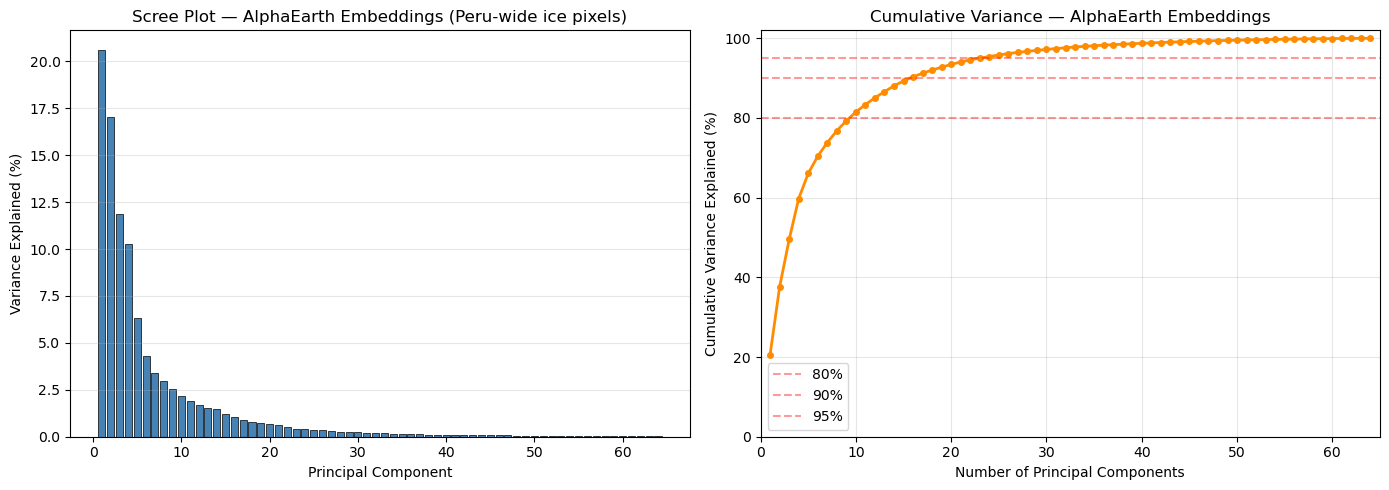

70% variance reached at PC6
80% variance reached at PC10
90% variance reached at PC16
95% variance reached at PC23
99% variance reached at PC43


In [17]:
# ============================================================
# CELL 3: SCREE PLOT
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 65), pca.explained_variance_ratio_ * 100, 
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — AlphaEarth Embeddings (Peru-wide ice pixels)')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, 65), cum_var, color='darkorange', linewidth=2, marker='o', 
             markersize=4)
for threshold, color in [(80, 'red'), (90, 'red'), (95, 'red')]:
    axes[1].axhline(threshold, linestyle='--', color=color, alpha=0.4, 
                    label=f'{threshold}%')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance — AlphaEarth Embeddings')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 65)
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig(LOCAL_DIR / 'pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print which k achieves common variance thresholds
for threshold in [70, 80, 90, 95, 99]:
    k = np.argmax(cum_var >= threshold) + 1
    print(f'{threshold}% variance reached at PC{k}')

In [18]:
# Mean separation between melt and non-melt classes in each PC
melt_mask = df_all['melt_label'].values == 1
melt_means = X_pca[melt_mask].mean(axis=0)
nonmelt_means = X_pca[~melt_mask].mean(axis=0)
diffs = np.abs(melt_means - nonmelt_means)

# Print all 20 most informative PCs ranked by separation
ranked = np.argsort(diffs)[::-1]
print(f'{"Rank":<5}{"PC":<6}{"|Δmean|":<10}{"VarExp%":<10}')
for rank, idx in enumerate(ranked[:20]):
    print(f'{rank+1:<5}{idx+1:<6}{diffs[idx]:<10.4f}{pca.explained_variance_ratio_[idx]*100:<10.3f}')

# Also: what fraction of total melt-discriminative power is in the top-k variance PCs?
total_diff = diffs.sum()
for k in [3, 6, 10, 15, 20]:
    top_k_idx = np.argsort(pca.explained_variance_ratio_)[::-1][:k]  # top-k by variance
    print(f'Top {k:2d} variance-ranked PCs capture '
          f'{diffs[top_k_idx].sum()/total_diff*100:.1f}% of total melt separation')

Rank PC    |Δmean|   VarExp%   
1    3     3.5717    11.863    
2    1     1.4791    20.627    
3    5     1.3720    6.310     
4    2     0.9786    17.023    
5    4     0.8555    10.263    
6    11    0.3753    1.890     
7    8     0.3457    2.945     
8    16    0.2245    1.045     
9    12    0.1703    1.689     
10   19    0.1634    0.724     
11   6     0.1592    4.328     
12   10    0.1549    2.155     
13   9     0.1294    2.547     
14   17    0.1278    0.895     
15   13    0.1049    1.545     
16   24    0.0919    0.402     
17   20    0.0823    0.693     
18   18    0.0761    0.800     
19   15    0.0705    1.218     
20   14    0.0587    1.461     
Top  3 variance-ranked PCs capture 54.1% of total melt separation
Top  6 variance-ranked PCs capture 75.5% of total melt separation
Top 10 variance-ranked PCs capture 81.7% of total melt separation
Top 15 variance-ranked PCs capture 88.7% of total melt separation
Top 20 variance-ranked PCs capture 94.7% of total melt separatio